### prep chai array-like

In [4]:
import pandas as pd
import yaml
from pathlib import Path
import config



MERGED_PATH =  (config.RAW_DATA_DIR / "merged.csv")
df = pd.read_csv(MERGED_PATH)

df.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,esmfold_esm3dg_dg_b,esmfold_esm3dg_dg_std,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,alphaseq,original,p14_MIT,1,NaN,2.972237,94.697017,13.940,2.015,2.350111,...,-0.546701,0.101401,0.139049,1.972964,1.119742,2.826187,"[[0.9514503479003906, 0.9545209407806396, 0.06...","[[[0.9514503479003906, 0.8910385966300964, 0.0...","[[0.9505935311317444, 0.9539876580238342, 0.06...","[[[0.9505935311317444, 0.8912463188171387, 0.0..."
1,alphaseq,original,p91_MIT,1,NaN,4.029266,92.250682,80.815,9.660,2.986979,...,-0.360552,0.135632,0.118062,2.136583,1.305839,2.967328,"[[0.9595669507980347, 0.9512633085250854, 0.07...","[[[0.9595669507980347, 0.8984649181365967, 0.0...","[[0.9608021378517151, 0.9524312615394592, 0.08...","[[[0.9608021378517151, 0.9030640125274658, 0.0..."
2,alphaseq,original,p95_MIT,1,NaN,4.194794,90.716169,115.715,11.300,2.284325,...,-0.341186,0.190724,0.120972,2.113158,1.235618,2.990697,"[[0.9497082233428955, 0.9363498687744141, 0.06...","[[[0.9497082233428955, 0.8772153258323669, 0.0...","[[0.9499721527099609, 0.9373988509178162, 0.06...","[[[0.9499721527099609, 0.8792778253555298, 0.0..."
3,alphaseq,dms,AAYL49_15172_MIT,1,NaN,4.153689,90.213944,115.005,15.110,4.195769,...,-0.577968,0.090316,0.139893,1.967060,1.114227,2.819892,"[[0.9523726105690002, 0.9536397457122803, 0.06...","[[[0.9523726105690002, 0.8923112750053406, 0.0...","[[0.9523597955703735, 0.9536870718002319, 0.06...","[[[0.9523597955703735, 0.8931128978729248, 0.0..."
4,alphaseq,dms,AAYL50_983_MIT,1,NaN,2.905619,94.757097,23.300,3.090,2.507738,...,-0.569774,0.123308,0.134209,2.008408,1.192651,2.824166,"[[0.9509323239326477, 0.9527089595794678, 0.06...","[[[0.9509323239326477, 0.8878659009933472, 0.0...","[[0.9565910696983337, 0.952727735042572, 0.104...","[[[0.9565910696983337, 0.8963015675544739, 0.0..."


### prep chai array-like

In [ ]:
# TO DO: i need to do this for all my dfs, also refactor to a function (it selects only the columns needed for the chai matrices)
def select_chai_columns(df):
    return df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]

chai_df = select_chai_columns(df)
chai_df.to_csv(config.PROCESSED_DATA_DIR / 'chai_matrices.csv', index=False)
chai_df.head()

,sample,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,p14_MIT,"[[0.9514503479003906, 0.9545209407806396, 0.06...","[[[0.9514503479003906, 0.8910385966300964, 0.0...","[[0.9505935311317444, 0.9539876580238342, 0.06...","[[[0.9505935311317444, 0.8912463188171387, 0.0..."
1,p91_MIT,"[[0.9595669507980347, 0.9512633085250854, 0.07...","[[[0.9595669507980347, 0.8984649181365967, 0.0...","[[0.9608021378517151, 0.9524312615394592, 0.08...","[[[0.9608021378517151, 0.9030640125274658, 0.0..."
2,p95_MIT,"[[0.9497082233428955, 0.9363498687744141, 0.06...","[[[0.9497082233428955, 0.8772153258323669, 0.0...","[[0.9499721527099609, 0.9373988509178162, 0.06...","[[[0.9499721527099609, 0.8792778253555298, 0.0..."
3,AAYL49_15172_MIT,"[[0.9523726105690002, 0.9536397457122803, 0.06...","[[[0.9523726105690002, 0.8923112750053406, 0.0...","[[0.9523597955703735, 0.9536870718002319, 0.06...","[[[0.9523597955703735, 0.8931128978729248, 0.0..."
4,AAYL50_983_MIT,"[[0.9509323239326477, 0.9527089595794678, 0.06...","[[[0.9509323239326477, 0.8878659009933472, 0.0...","[[0.9565910696983337, 0.952727735042572, 0.104...","[[[0.9565910696983337, 0.8963015675544739, 0.0..."


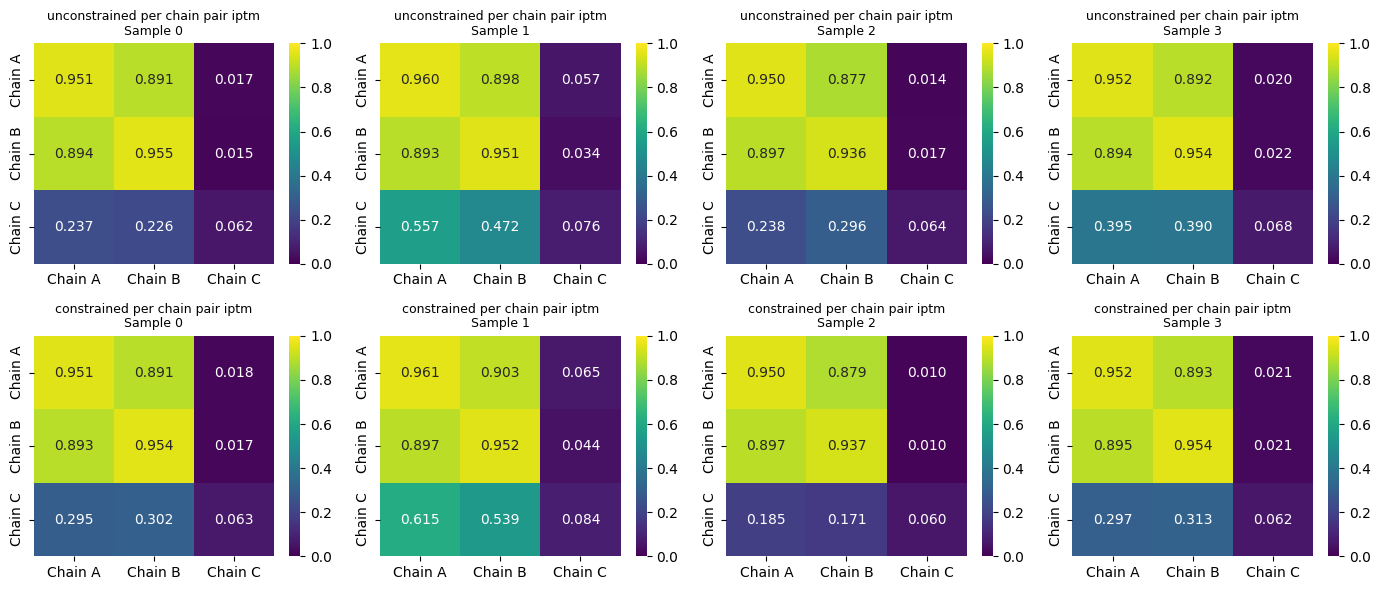

In [ ]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(config.PROCESSED_DATA_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [8]:
# Extract min from pair_iptm matrices
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_pair_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_pair_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_pair_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_pair_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.014588
1    0.034106
2    0.013545
3    0.019671
4    0.011299
5    0.014605
6    0.007764
7    0.011784
8    0.020491
9    0.015233

Constrained A-B interface min (top 10):
0    0.017320
1    0.044448
2    0.009858
3    0.020659
4    0.043300
5    0.017007
6    0.011149
7    0.012736
8    0.039894
9    0.019490


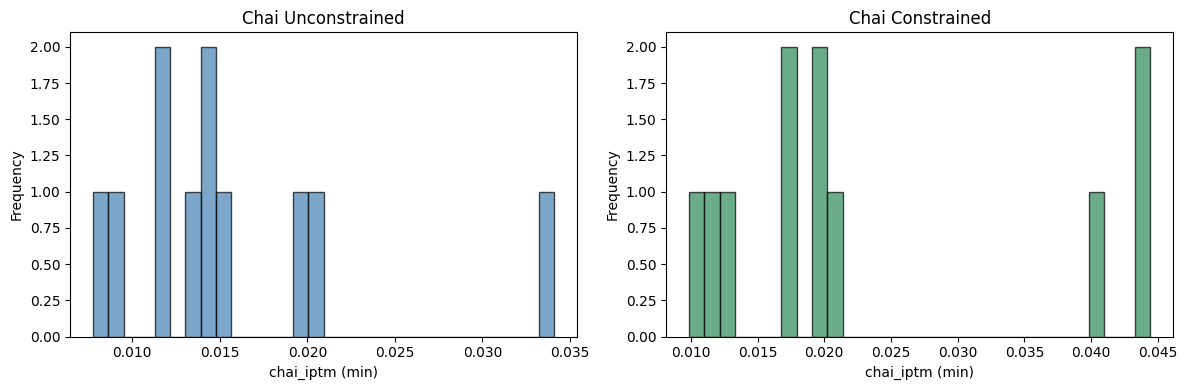

In [ ]:
# # TO DO: refactor to a function (it visualizes the distribution of the min pair_iptm values for both constrained and unconstrained cases and saves the figure)
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(config.PROCESSED_DATA_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Extract mean pTM (mean over the whole structure, all 3 chains)
def extract_ptm_mean(arr):
    """Extract mean of pTM array"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.mean(arr)

# Extract mean for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Extract mean for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Display summary

print("\nUnconstrained pTM mean (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM mean (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM mean - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM mean - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM mean (top 10):
0    0.655839
1    0.662386
2    0.650132
3    0.658154
4    0.654681
5    0.655121
6    0.650648
7    0.651873
8    0.656891
9    0.653076

Constrained pTM mean (top 10):
0    0.655847
1    0.665721
2    0.649139
3    0.656065
4    0.671395
5    0.657436
6    0.648672
7    0.652265
8    0.670275
9    0.653979

Unconstrained pTM mean - desc stats:
count    11.000000
mean      0.654090
std       0.004400
min       0.646186
25%       0.651261
50%       0.654681
75%       0.656365
max       0.662386
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM mean - desc stats:
count    11.000000
mean      0.657411
std       0.008137
min       0.648672
25%       0.651494
50%       0.655847
75%       0.661579
max       0.671395
Name: chai_constrained_per_chain_ptm, dtype: float64


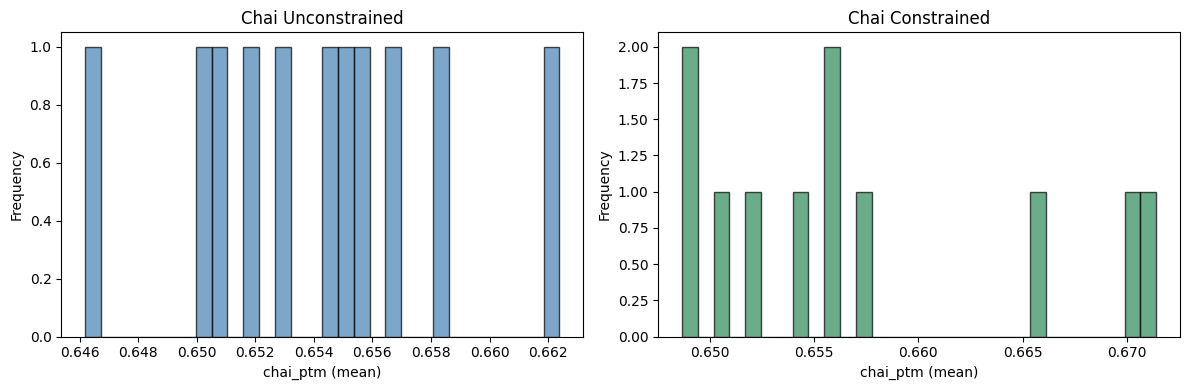

In [ ]:
# # TO DO: refactor to a function (it visualizes the distribution of the min pair_iptm values for both constrained and unconstrained cases and saves the figure) 
# --> same es before but for the mean pTM values instead of the min pair_iptm values, any idea to generalize?
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (mean)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (mean)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(config.PROCESSED_DATA_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# TO DO: also refactor to a function (it creates a new df with only the columns needed for the final analysis, in this case the mean pTM and min pair_iptm values for both constrained and unconstrained cases, and saves it as a csv)
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_pair_iptm',
                            'chai_constrained_per_chain_pair_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(config.PROCESSED_DATA_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (11, 5)

df_chai_numeric head:
             sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0           p14_MIT                          0.655839                        0.655847                                0.014588                              0.017320
1           p91_MIT                          0.662386                        0.665721                                0.034106                              0.044448
2           p95_MIT                          0.650132                        0.649139                                0.013545                              0.009858
3  AAYL49_15172_MIT                          0.658154                        0.656065                                0.019671                              0.020659
4    AAYL50_983_MIT                          0.654681                        0.671395                                0.011299 

In [13]:
# TO DO: drop the original matrix columns from the original df (not the new one) to save memory, also refactor to a function
df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
df.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,esmfold2_mpnn_nll_a,esmfold2_mpnn_nll_b,esmfold_esm3dg_dg,esmfold_esm3dg_dg_a,esmfold_esm3dg_dg_b,esmfold_esm3dg_dg_std,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b
0,alphaseq,original,p14_MIT,1,NaN,2.972237,94.697017,13.940,2.015,2.350111,...,1.063680,2.604460,2.124459,4.795619,-0.546701,0.101401,0.139049,1.972964,1.119742,2.826187
1,alphaseq,original,p91_MIT,1,NaN,4.029266,92.250682,80.815,9.660,2.986979,...,1.207068,2.183162,2.539031,5.438615,-0.360552,0.135632,0.118062,2.136583,1.305839,2.967328
2,alphaseq,original,p95_MIT,1,NaN,4.194794,90.716169,115.715,11.300,2.284325,...,1.159031,2.470168,2.515744,5.372673,-0.341186,0.190724,0.120972,2.113158,1.235618,2.990697
3,alphaseq,dms,AAYL49_15172_MIT,1,NaN,4.153689,90.213944,115.005,15.110,4.195769,...,1.053183,1.959977,2.116123,4.810214,-0.577968,0.090316,0.139893,1.967060,1.114227,2.819892
4,alphaseq,dms,AAYL50_983_MIT,1,NaN,2.905619,94.757097,23.300,3.090,2.507738,...,1.014729,1.582581,1.991878,4.553530,-0.569774,0.123308,0.134209,2.008408,1.192651,2.824166


In [ ]:
# TO DO: refactor to a function (it joins the scores_df with the new df_chai_numeric on the "sample" column, and then it prints some statistics about the join, like how many rows have missing values in the new columns, etc.)
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(config.PROCESSED_DATA_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {config.PROCESSED_DATA_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (11, 139)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

scores_df_extended head:
             sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0           p14_MIT                          0.655839                        0.655847                                0.014588                              0.017320
1           p91_MIT                          0.662386                        0.665721                                0.034106                              0.044448
2           p95_MIT                          0.650132                        0.649139                                0.013545                              0.009858
3  AAYL49_15172_MIT                          0.658154                        0.656065     

In [15]:
scores_df_extended.head()

,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,esmfold_esm3dg_dg_b,esmfold_esm3dg_dg_std,esmfold_mpnn_confidence,esmfold_mpnn_nll,esmfold_mpnn_nll_a,esmfold_mpnn_nll_b,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm
0,alphaseq,original,p14_MIT,1,NaN,2.972237,94.697017,13.940,2.015,2.350111,...,-0.546701,0.101401,0.139049,1.972964,1.119742,2.826187,0.655839,0.655847,0.014588,0.017320
1,alphaseq,original,p91_MIT,1,NaN,4.029266,92.250682,80.815,9.660,2.986979,...,-0.360552,0.135632,0.118062,2.136583,1.305839,2.967328,0.662386,0.665721,0.034106,0.044448
2,alphaseq,original,p95_MIT,1,NaN,4.194794,90.716169,115.715,11.300,2.284325,...,-0.341186,0.190724,0.120972,2.113158,1.235618,2.990697,0.650132,0.649139,0.013545,0.009858
3,alphaseq,dms,AAYL49_15172_MIT,1,NaN,4.153689,90.213944,115.005,15.110,4.195769,...,-0.577968,0.090316,0.139893,1.967060,1.114227,2.819892,0.658154,0.656065,0.019671,0.020659
4,alphaseq,dms,AAYL50_983_MIT,1,NaN,2.905619,94.757097,23.300,3.090,2.507738,...,-0.569774,0.123308,0.134209,2.008408,1.192651,2.824166,0.654681,0.671395,0.011299,0.043300
